# Week 2

## 2.1

1. The random models condensed the required information to create the networks, so you understood how it functioned at it's most basic level. And the math was so simply that you could do most of the math with pen and paper. They are still used today, because they are where people get the intuition about the networks, even the real ones today. And it is needed because there was no data.

2. With mean less than one, branches tends to die, whereas with mean more than one they tend to grow and swallow the rest.

3. 
![Linear vs log–log sketches of a random (Poisson) degree distribution and a heavy-tailed distribution, both with mean 10](2.3.jpeg)
 
4. The more informative is the 17 for the real network. This shows that there is something in the real network that is not statisticly independent, because if it where, it would be closer to the statistical number. This cannot be seen from the average degree.

5. $<m> = 3$, $<k> = 1$, $<isolated> = 0.33$, $<m_{marvel}> = 1346$ (1434 observed)

## 2.2 — The random network, as code

🚀 **Builder.** $G(n,p)$ with $p = \langle k\rangle/(n-1)$. Poisson overlay first, then the $\langle k\rangle=1$ transition, a barely-connected drawing, and a Marvel $n$, $m$ comparison table (kept for Parts 4 and 7).


In [2]:
from math import lgamma, log, pi, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

rng = np.random.default_rng(2)


def poisson_pmf(ks, lam):
    ks = np.asarray(ks, dtype=int)
    out = np.empty(ks.size, dtype=float)
    for i, k in enumerate(ks.ravel()):
        if k < 0:
            out[i] = 0.0
        else:
            out[i] = np.exp(k * log(lam) - lam - lgamma(k + 1))
    return out.reshape(ks.shape)


def normal_pdf(x, mu, var):
    return np.exp(-0.5 * (x - mu) ** 2 / var) / np.sqrt(2 * pi * var)


def giant_component(G):
    return max(nx.connected_components(G), key=len)


def poisson_typical_kmax(n, lam, k_hi=80):
    """Smallest k with n * P(K >= k) <= 1 (a rough prediction for the max)."""
    ks = np.arange(0, k_hi + 1)
    pmf = poisson_pmf(ks, lam)
    surv = np.cumsum(pmf[::-1])[::-1]
    hit = np.where(n * surv <= 1)[0]
    return int(hit[0]) if len(hit) else k_hi


### 1 · Degree distribution vs Poisson (then Normal)

$n = 5000$, $\langle k\rangle = 10$ so $p = 10/(n-1)$. Expected edges: $p\,n(n-1)/2 = n\langle k\rangle/2 = 25{,}000$.


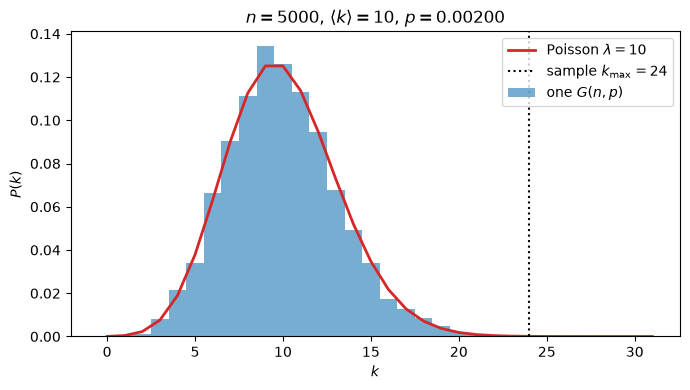

p = ⟨k⟩/(n-1) = 0.002000
m = 24876  (expected n⟨k⟩/2 = 25000)
sample ⟨k⟩ = 9.950  (target 10.0)
sample k_max = 24  vs Poisson n P(K>=k)≈1 at k≈24
hand check: p*(n-1) = 10 exactly; generated m is within sampling noise of 25000.


In [3]:
n, k_mean = 5000, 10.0
p = k_mean / (n - 1)
G10 = nx.gnp_random_graph(n, p, seed=2)
degrees10 = np.array([d for _, d in G10.degree()])
ks10, counts10 = np.unique(degrees10, return_counts=True)
pk10 = counts10 / n
k_grid10 = np.arange(0, degrees10.max() + 8)
kmax_pred = poisson_typical_kmax(n, k_mean)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ks10, pk10, width=1.0, align="center", alpha=0.6, label="one $G(n,p)$")
ax.plot(k_grid10, poisson_pmf(k_grid10, k_mean), color="C3", lw=2, label=rf"Poisson $\lambda={k_mean:.0f}$")
ax.axvline(degrees10.max(), color="k", ls=":", label=rf"sample $k_{{\max}}={degrees10.max()}$")
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$P(k)$")
ax.set_title(rf"$n={n}$, $\langle k\rangle={k_mean:.0f}$, $p={p:.5f}$")
ax.legend()
fig.tight_layout()
plt.show()

print(f"p = ⟨k⟩/(n-1) = {p:.6f}")
print(f"m = {G10.number_of_edges()}  (expected n⟨k⟩/2 = {n * k_mean / 2:.0f})")
print(f"sample ⟨k⟩ = {degrees10.mean():.3f}  (target {k_mean})")
print(f"sample k_max = {degrees10.max()}  vs Poisson n P(K>=k)≈1 at k≈{kmax_pred}")
print("hand check: p*(n-1) = 10 exactly; generated m is within sampling noise of 25000.")


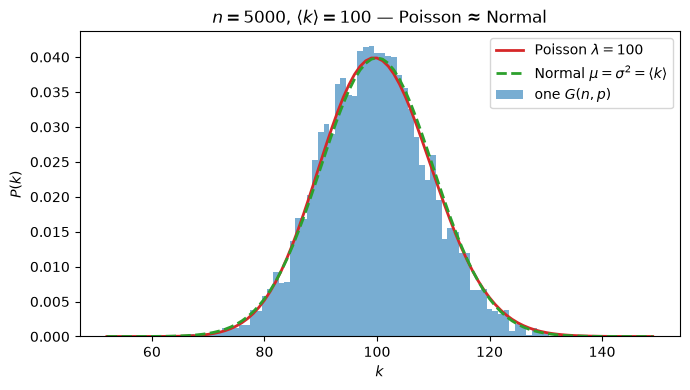

Yes: with ⟨k⟩=100 the Poisson is already bell-shaped, so the Normal with the same mean and variance sits on top of it.


In [4]:
k_mean100 = 100.0
p100 = k_mean100 / (n - 1)
G100 = nx.gnp_random_graph(n, p100, seed=2)
degrees100 = np.array([d for _, d in G100.degree()])
ks100, counts100 = np.unique(degrees100, return_counts=True)
pk100 = counts100 / n
k_grid100 = np.arange(degrees100.min() - 15, degrees100.max() + 16)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ks100, pk100, width=1.0, align="center", alpha=0.6, label="one $G(n,p)$")
ax.plot(k_grid100, poisson_pmf(k_grid100, k_mean100), color="C3", lw=2, label=r"Poisson $\lambda=100$")
ax.plot(
    k_grid100,
    normal_pdf(k_grid100, k_mean100, k_mean100),
    color="C2",
    lw=2,
    ls="--",
    label=r"Normal $\mu=\sigma^2=\langle k\rangle$",
)
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$P(k)$")
ax.set_title(rf"$n={n}$, $\langle k\rangle={k_mean100:.0f}$ — Poisson ≈ Normal")
ax.legend()
fig.tight_layout()
plt.show()

print("Yes: with ⟨k⟩=100 the Poisson is already bell-shaped, so the Normal with the same mean and variance sits on top of it.")


### 2 · Giant-component phase transition

$n=1000$, $\langle k\rangle$ from 0.2 to 4, 20 graphs per point. Error bars are the standard deviation over those 20 runs. The page's infinite-network theory jumps at $\langle k\rangle=1$; a finite $n$ rounds that corner a bit.


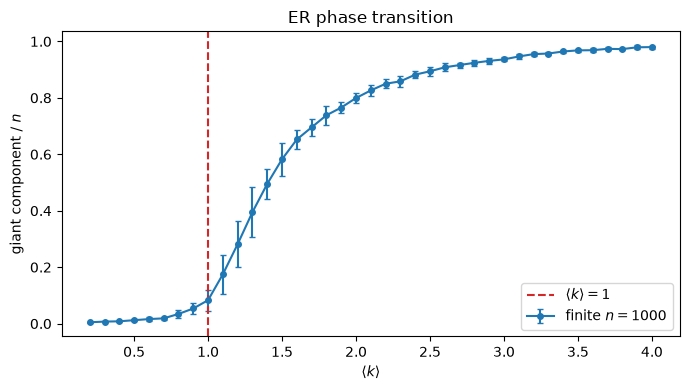

The giant fraction stays near 0 below 1, then rises steeply just after 1 — same shape as the explorable, a bit rounded because n is finite.


In [5]:
n_pt = 1000
k_vals = np.arange(0.2, 4.01, 0.1)
n_rep = 20
frac_mean = []
frac_std = []

for kbar in k_vals:
    p = kbar / (n_pt - 1)
    fracs = []
    for r in range(n_rep):
        G = nx.gnp_random_graph(n_pt, p, seed=int(1000 * kbar + r))
        gcc = max(len(c) for c in nx.connected_components(G))
        fracs.append(gcc / n_pt)
    frac_mean.append(np.mean(fracs))
    frac_std.append(np.std(fracs, ddof=1))

frac_mean = np.array(frac_mean)
frac_std = np.array(frac_std)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(k_vals, frac_mean, yerr=frac_std, fmt="o-", ms=4, capsize=2, label="finite $n=1000$")
ax.axvline(1.0, color="C3", ls="--", label=r"$\langle k\rangle=1$")
ax.set_xlabel(r"$\langle k\rangle$")
ax.set_ylabel("giant component / $n$")
ax.set_title("ER phase transition")
ax.legend()
fig.tight_layout()
plt.show()

print("The giant fraction stays near 0 below 1, then rises steeply just after 1 — same shape as the explorable, a bit rounded because n is finite.")


### 3 · A random network just above the transition


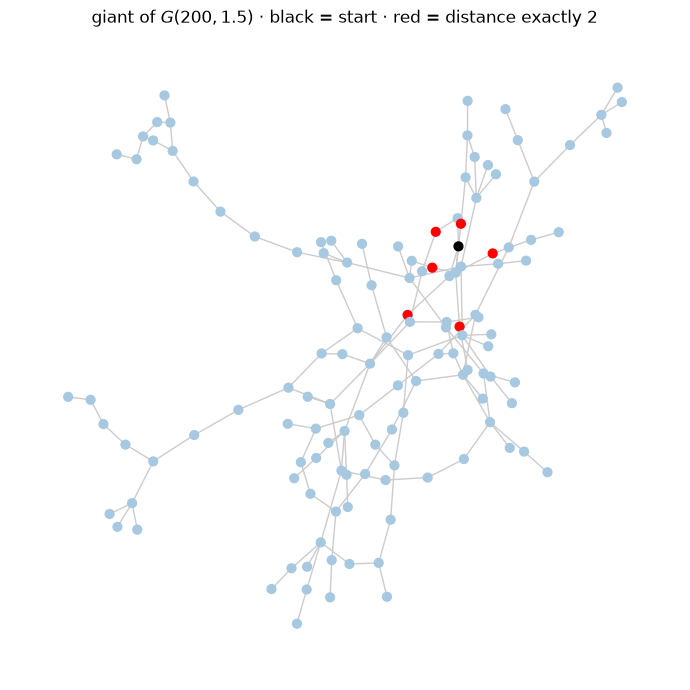

giant size 130 / 200
nodes at distance 2 from 163: 6
eccentricity of start: 14


In [5]:
n_draw, k_draw = 200, 1.5
p_draw = k_draw / (n_draw - 1)
G_draw = nx.gnp_random_graph(n_draw, p_draw, seed=7)
gcc_nodes = giant_component(G_draw)
H = G_draw.subgraph(gcc_nodes).copy()
start = int(rng.choice(list(H.nodes())))
dist = nx.single_source_shortest_path_length(H, start)
color = []
for v in H.nodes():
    if v == start:
        color.append("black")
    elif dist.get(v) == 2:
        color.append("red")
    else:
        color.append("#a6c8e0")

pos = nx.spring_layout(H, seed=7)
fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx(
    H, pos=pos, ax=ax, node_size=40, node_color=color, edge_color="#cccccc", with_labels=False
)
ax.set_title(rf"giant of $G({n_draw},{k_draw})$ · black = start · red = distance exactly 2")
ax.axis("off")
fig.tight_layout()
plt.show()

print(f"giant size {H.number_of_nodes()} / {n_draw}")
print(f"nodes at distance 2 from {start}: {sum(1 for d in dist.values() if d == 2)}")
print(f"eccentricity of start: {max(dist.values())}")


Near $\langle k\rangle=1.5$ the giant is a **thin, treelike web**, not a hairball. A path is a sequence of edges; from the black node, red nodes are those two hops away. Because there are almost no extra triangles, those red nodes sit on distinct branches — “two steps” still fans out, but the branches are long and stringy, so the far side of the giant is still several hops further. Short paths exist, but the network is barely hanging together.


### 4 · Random Marvel vs the real network

Undirected comparison: real $n=303$, $m=1434$ (week-1 page). Random: $G(n,m)$ with those counts. Table kept for Parts 4 and 7.


In [6]:
data_dir = Path("../uge1") if Path("../uge1/week1_nodes.tsv").exists() else Path("uge1")
nodes = pd.read_csv(data_dir / "week1_nodes.tsv", sep="\t", comment="#", quoting=3)
edges = pd.read_csv(
    data_dir / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"]
)
Marvel_dir = nx.DiGraph()
Marvel_dir.add_nodes_from(nodes.node_id)
Marvel_dir.add_edges_from(edges.itertuples(index=False))
Marvel = Marvel_dir.to_undirected()

n_m, m_m = Marvel.number_of_nodes(), Marvel.number_of_edges()
assert n_m == 303 and m_m == 1434

G_rand = nx.gnm_random_graph(n_m, m_m, seed=2)


def network_row(G, label):
    isolates = sum(1 for _, d in G.degree() if d == 0)
    kmax = max(d for _, d in G.degree())
    gcc = giant_component(G)
    H = G.subgraph(gcc)
    avg_d = nx.average_shortest_path_length(H)
    C = nx.average_clustering(G)
    return {
        "network": label,
        "n": G.number_of_nodes(),
        "m": G.number_of_edges(),
        "isolates": isolates,
        "giant size": H.number_of_nodes(),
        "avg distance (giant)": round(avg_d, 2),
        "k_max": kmax,
        "C": round(C, 3),
    }


table_22 = pd.DataFrame(
    [network_row(Marvel, "Marvel (undirected)"), network_row(G_rand, "random G(n, m)")]
)
print(table_22.to_string(index=False))

print("Page: random Marvel avg distance ~2.8, almost no isolates, k_max around 19, C ≈ p ≈ 0.03.")
print("Real: isolates 17, giant 277, C ≈ 0.31, Spider-Man-scale hubs — chance matches distance, not clustering or hubs.")


            network   n    m  isolates  giant size  avg distance (giant)  k_max     C
Marvel (undirected) 303 1434        17         277                  2.67    106 0.307
     random G(n, m) 303 1434         0         303                  2.77     18 0.022
Page: random Marvel avg distance ~2.8, almost no isolates, k_max around 19, C ≈ p ≈ 0.03.
Real: isolates 17, giant 277, C ≈ 0.31, Spider-Man-scale hubs — chance matches distance, not clustering or hubs.


## 2.3

1. 1/3, 2/3, 1

2. 2/3, 1, 2/3, 1/3, 0, 0. C = 4/9. C_F is 0 because it only has one neighbor, and C_E is 0 because the two neighbors it has dont link.

3. 33, A lot of people connect to a page (hub), but they dont nesecarrily (and often dont) link/know each other. C_i is meaninless at degree 1, because you only have one neighbor, so they cannot link to anything (we dont self-link). 

4. Transitivity is pulled down. A lot connect to the hubs, but they dont often connect to each other. I would think they would be the same if all nodes have equal degree.

5. Distance is correct (along with n and m, of course)

## 2.4

1. $q=0$, largest distance and clustering. $q=0.01$, second highest distance, second highest clustering (still high). $q=1$, lowest clustering, lowest distance. 


### 2 · Classic Watts–Strogatz figure

$n=500$, $\langle k\rangle=k=4$, 50 graphs per $q$. Error bars = standard deviation over those 50. Both series are divided by the $q=0$ lattice so you can see distance collapse while clustering holds (the explorable’s right-hand panel).


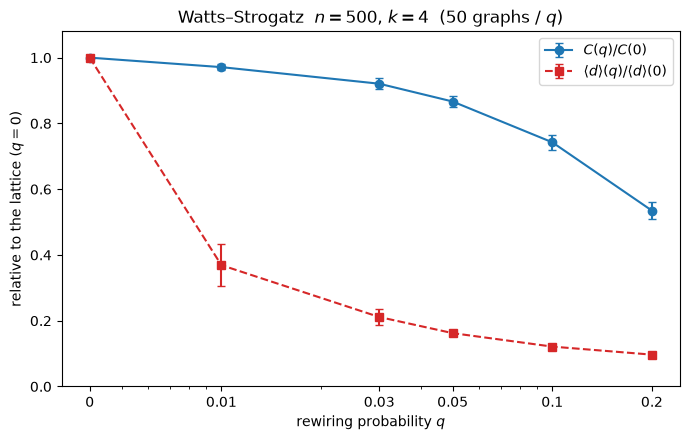

q      C              ⟨d⟩
0.00  0.500 ± 0.000   62.88 ± 0.00
0.01  0.486 ± 0.004   23.20 ± 3.98
0.03  0.460 ± 0.009   13.28 ± 1.52
0.05  0.433 ± 0.008   10.20 ± 0.62
0.10  0.371 ± 0.012   7.63 ± 0.20
0.20  0.267 ± 0.013   6.09 ± 0.12
hand check: ring lattice (k=4) has C = 3(k-2)/(4(k-1)) = 0.50; we got C(0)=0.500.
⟨d⟩ collapses by q=0.01 while C is still high — that is the small-world window.


In [7]:
# 2.4.2 — Watts–Strogatz: C and ⟨d⟩ vs q (classic small-world figure)
n_ws, k_ws, n_rep_ws = 500, 4, 50
q_vals = np.array([0.0, 0.01, 0.03, 0.05, 0.1, 0.2])

C_mean, C_std, d_mean, d_std = [], [], [], []
for q in q_vals:
    Cs, ds = [], []
    for r in range(n_rep_ws):
        G = nx.watts_strogatz_graph(n_ws, k_ws, q, seed=int(10_000 * q + r))
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        Cs.append(nx.average_clustering(G))
        ds.append(nx.average_shortest_path_length(G))
    C_mean.append(np.mean(Cs))
    C_std.append(np.std(Cs, ddof=1))
    d_mean.append(np.mean(ds))
    d_std.append(np.std(ds, ddof=1))

C_mean, C_std = np.array(C_mean), np.array(C_std)
d_mean, d_std = np.array(d_mean), np.array(d_std)

# q=0 cannot sit on a log axis; plot it just left of 0.01 and label it 0
q_plot = np.where(q_vals == 0, 4e-3, q_vals)
C0, d0 = C_mean[0], d_mean[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    q_plot, C_mean / C0, yerr=C_std / C0, fmt="o-", color="C0", capsize=3, label=r"$C(q)/C(0)$"
)
ax.errorbar(
    q_plot, d_mean / d0, yerr=d_std / d0, fmt="s--", color="C3", capsize=3, label=r"$\langle d\rangle(q)/\langle d\rangle(0)$"
)
ax.set_xscale("log")
ax.set_xticks(q_plot)
ax.set_xticklabels(["0" if q == 0 else str(q) for q in q_vals])
ax.set_xlabel(r"rewiring probability $q$")
ax.set_ylabel("relative to the lattice ($q=0$)")
ax.set_title(rf"Watts–Strogatz  $n={n_ws}$, $k={k_ws}$  ({n_rep_ws} graphs / $q$)")
ax.legend()
ax.set_ylim(0, 1.08)
fig.tight_layout()
plt.show()

print("q      C              ⟨d⟩")
for q, C, d in zip(q_vals, C_mean, d_mean):
    print(f"{q:4.2f}  {C:.3f} ± {C_std[q_vals.tolist().index(q)]:.3f}   {d:.2f} ± {d_std[q_vals.tolist().index(q)]:.2f}")

print(f"hand check: ring lattice (k=4) has C = 3(k-2)/(4(k-1)) = {3 * (k_ws - 2) / (4 * (k_ws - 1)):.2f}; we got C(0)={C0:.3f}.")
print("⟨d⟩ collapses by q=0.01 while C is still high — that is the small-world window.")


### 3–4 · Figure caption and $q=1$ *(catch-up, Learn)*

**Asked.** Caption the 2.4 figure; say around which $q$ the network becomes small, why $C$ holds longer than $\langle d\rangle$, and what the network is at $q=1$.

**Caption.** Horizontal axis: rewiring probability $q$ on a log scale (the lattice $q=0$ is plotted just left of $0.01$ so it can sit on the same axis). Vertical axis: clustering $C(q)$ and mean shortest path $\langle d\rangle(q)$, each divided by its lattice value so both start at 1. Error bars are the standard deviation across 50 independent Watts–Strogatz graphs at that $q$. What to notice: $\langle d\rangle$ has already collapsed by $q=0.01$, while $C$ is still close to the lattice; that gap is the small-world window.

**Around which $q$ is it “small”?** Already around $q \approx 0.01$: distances are near the random-graph value, clustering is not. On the test, “small world” means *both* — clustering far above chance *and* distances at chance.

**Why $C$ holds longer — without “shortcut”.** Almost all of a node’s neighbors are still its lattice neighbors, so those neighbors are still linked to each other. The few rewired links only change a tiny fraction of neighborhoods, so the local triangle fraction barely moves, while global paths can jump across the ring.

**With “shortcut”.** Each rewired link is a long-range shortcut. A handful of shortcuts collapse $\langle d\rangle$ from $O(n)$ to $O(\log n)$; clustering lives in the unre wired majority, so $C$ decays only when $q$ is large enough to tear up local neighborhoods.

**Closed-book takeaway (On the test).** Small-world signature = high $C$ + short paths. Mechanism = a few shortcuts. Distances move first as $q$ grows.

**4. What is $q=1$?** Every lattice edge has been rewired to a random destination, so the *pattern* is like a random graph: low clustering, short paths. It is **not exactly** $G(n,p)$. Watts–Strogatz rewiring **preserves every node’s degree** ($k=4$ here, or $k\pm$ a small amount depending on the exact rewiring rule). A true Erdős–Rényi graph has a Poisson degree distribution, so some nodes can have degree $0$ or $1$. At $q=1$ the minimum degree is still $\approx k$ — no isolates, no hubs. That leftover regularity is the giveaway.


## 2.5b — Preferential attachment 🔬 Tool

Grow-by-attachment models: endpoint-list preferential attachment, validation against `nx.barabasi_albert_graph`, uniform growth, and a matched random null.

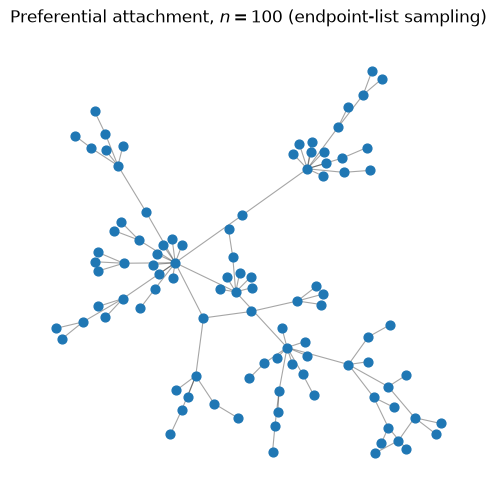

100-node PA graph: 100 nodes, 99 edges


In [9]:
from collections import Counter

# --- helpers (week-1 binning + CCDF) ---------------------------------------

def endpoint_list(G):
    """Flat list of endpoints: each edge contributes both ends once."""
    return [n for u, v in G.edges() for n in (u, v)]


def grow_attachment_graph(n_target, preferential=True, seed=42):
    """Start with one edge between nodes 0 and 1; add one link per new node."""
    G = nx.Graph()
    G.add_edge(0, 1)
    rng = np.random.default_rng(seed)
    next_id = 2
    while G.number_of_nodes() < n_target:
        if preferential:
            target = int(rng.choice(endpoint_list(G)))  # proportional to degree
        else:
            target = int(rng.choice(list(G.nodes())))  # uniform over nodes
        G.add_edge(next_id, target)
        next_id += 1
    return G


def raw_pk(degree_sequence, n_nodes):
    counts = Counter(degree_sequence)
    k = np.array(sorted(counts))
    p = np.array([counts[ki] / n_nodes for ki in k])
    return k, p


def official_binning(degree_sequence, n_nodes, u_max=512):
    u = np.asarray(degree_sequence) + 1
    xs, ys = [], []
    for ui in range(1, 8):
        count = np.sum(u == ui)
        xs.append(ui)
        ys.append(count / n_nodes)
    lo = 8
    while lo < u_max:
        hi = lo * 2
        count = np.sum((u >= lo) & (u < hi))
        width = hi - lo
        xs.append(np.sqrt(lo * (hi - 1)))
        ys.append(count / width / n_nodes)
        lo = hi
    return np.array(xs), np.array(ys)


def plot_ccdf(degree_sequence, n_nodes, ax, label, **kwargs):
    ks = np.sort(np.unique(degree_sequence))
    ccdf_y = np.array([np.sum(np.asarray(degree_sequence) >= k) / n_nodes for k in ks])
    ax.loglog(ks + 1, ccdf_y, label=label, **kwargs)
    return ks + 1, ccdf_y


def loglog_slope(x, y, x_min=8):
    """OLS slope on log–log binned tail (skip small-k shoulder)."""
    mask = (x >= x_min) & (y > 0)
    return np.polyfit(np.log10(x[mask]), np.log10(y[mask]), 1)[0]


# --- 1 · 100-node preferential-attachment network ----------------------------

G100_pa = grow_attachment_graph(100, preferential=True, seed=42)
fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(G100_pa, seed=42)
nx.draw_networkx_nodes(G100_pa, pos, node_size=40, node_color="C0", ax=ax)
nx.draw_networkx_edges(G100_pa, pos, alpha=0.35, width=0.8, ax=ax)
ax.set_title("Preferential attachment, $n=100$ (endpoint-list sampling)")
ax.axis("off")
plt.show()
print(f"100-node PA graph: {G100_pa.number_of_nodes()} nodes, {G100_pa.number_of_edges()} edges")

Preferential attachment  n=5000
  edges m = 4999
  degree min = 1, max = 127


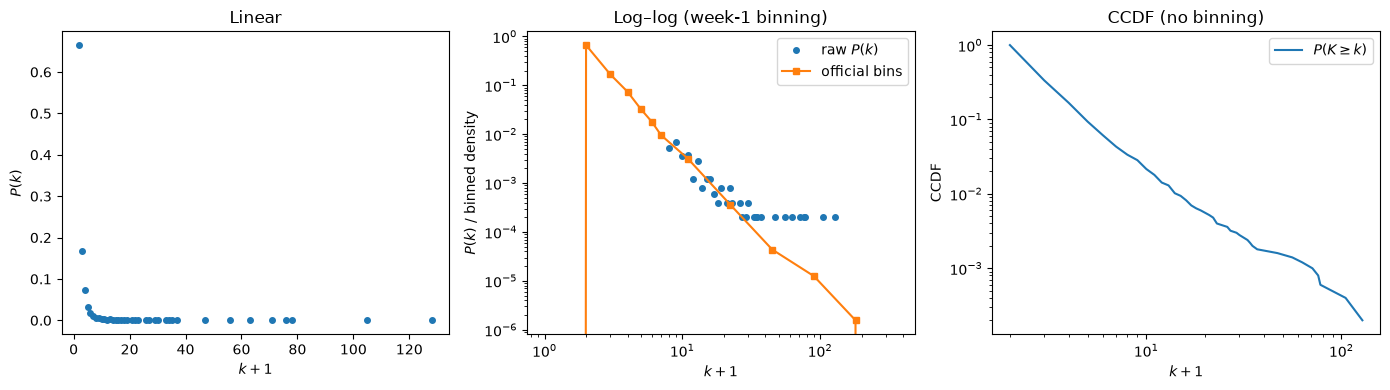

In [10]:
# --- 2 · n = 5000 preferential attachment: degrees + distributions -----------

N = 5000
G_pa = grow_attachment_graph(N, preferential=True, seed=42)
deg_pa = np.array([d for _, d in G_pa.degree()])

print(f"Preferential attachment  n={N}")
print(f"  edges m = {G_pa.number_of_edges()}")
print(f"  degree min = {deg_pa.min()}, max = {deg_pa.max()}")

k_pa, p_pa = raw_pk(deg_pa, N)
bx_pa, by_pa = official_binning(deg_pa, N)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(k_pa + 1, p_pa, "o", ms=4)
axes[0].set_xlabel(r"$k+1$")
axes[0].set_ylabel(r"$P(k)$")
axes[0].set_title("Linear")

axes[1].plot(k_pa + 1, p_pa, "o", ms=4, label="raw $P(k)$")
axes[1].loglog(bx_pa, by_pa, "s-", ms=5, label="official bins")
axes[1].set_xlabel(r"$k+1$")
axes[1].set_ylabel(r"$P(k)$ / binned density")
axes[1].set_title("Log–log (week-1 binning)")
axes[1].legend()

plot_ccdf(deg_pa, N, axes[2], label=r"$P(K \geq k)$")
axes[2].set_xlabel(r"$k+1$")
axes[2].set_ylabel("CCDF")
axes[2].set_title("CCDF (no binning)")
axes[2].legend()

fig.tight_layout()
plt.show()

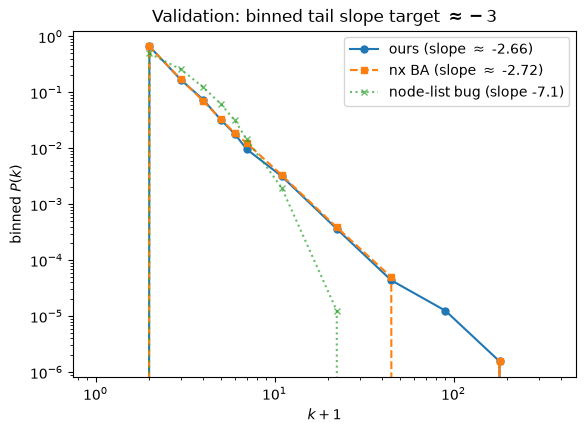

Validation (a) log–log binned slopes (tail from k+1 ≥ 8):
  endpoint-list PA : -2.66
  nx BA            : -2.72
  node-list bug    : -7.14  (max degree 15 — no hubs)

Validation (b) maximum degree:
  endpoint-list PA : 127
  nx BA            : 206
  Same straight tail on the plot — agreement up to sampling noise.


In [11]:
# --- 3 · Validation: slope ≈ −3 and agreement with NetworkX BA ---------------

G_ba = nx.barabasi_albert_graph(N, 1, seed=42)
deg_ba = np.array([d for _, d in G_ba.degree()])
bx_ba, by_ba = official_binning(deg_ba, N)

slope_pa = loglog_slope(bx_pa, by_pa)
slope_ba = loglog_slope(bx_ba, by_ba)

def grow_node_list_bug(n_target, seed=42):
    """Classic bug: uniform over nodes, not proportional to degree."""
    G = nx.Graph()
    G.add_edge(0, 1)
    rng = np.random.default_rng(seed)
    next_id = 2
    while G.number_of_nodes() < n_target:
        target = int(rng.choice(list(G.nodes())))
        G.add_edge(next_id, target)
        next_id += 1
    return G

G_wrong = grow_node_list_bug(N, seed=42)
deg_wrong = np.array([d for _, d in G_wrong.degree()])
bx_wrong, by_wrong = official_binning(deg_wrong, N)
slope_wrong = loglog_slope(bx_wrong, by_wrong)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(bx_pa, by_pa, "o-", ms=5, label=rf"ours (slope $\approx$ {slope_pa:.2f})")
ax.loglog(bx_ba, by_ba, "s--", ms=5, label=rf"nx BA (slope $\approx$ {slope_ba:.2f})")
ax.loglog(bx_wrong, by_wrong, "x:", ms=5, alpha=0.7, label=rf"node-list bug (slope {slope_wrong:.1f})")
ax.set_xlabel(r"$k+1$")
ax.set_ylabel(r"binned $P(k)$")
ax.set_title(r"Validation: binned tail slope target $\approx -3$")
ax.legend()
plt.show()

print("Validation (a) log–log binned slopes (tail from k+1 ≥ 8):")
print(f"  endpoint-list PA : {slope_pa:.2f}")
print(f"  nx BA            : {slope_ba:.2f}")
print(f"  node-list bug    : {slope_wrong:.2f}  (max degree {deg_wrong.max()} — no hubs)")

print("\nValidation (b) maximum degree:")
print(f"  endpoint-list PA : {deg_pa.max()}")
print(f"  nx BA            : {deg_ba.max()}")
print("  Same straight tail on the plot — agreement up to sampling noise.")

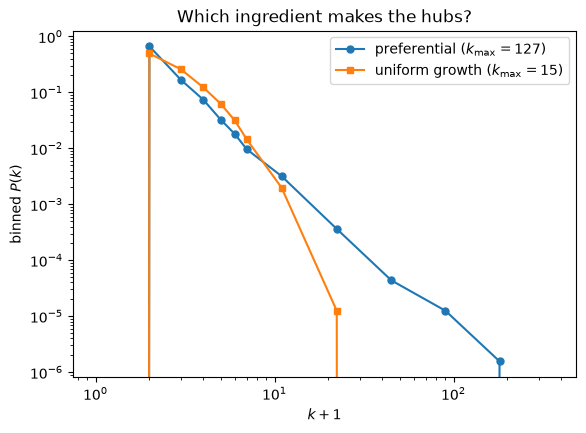

Uniform growth: min degree 1, max degree 15


In [12]:
# --- 4 · Uniform growth (same rule, no preferential attachment) --------------

G_uni = grow_attachment_graph(N, preferential=False, seed=42)
deg_uni = np.array([d for _, d in G_uni.degree()])
bx_uni, by_uni = official_binning(deg_uni, N)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(bx_pa, by_pa, "o-", ms=5, label=rf"preferential ($k_{{\max}}={deg_pa.max()}$)")
ax.loglog(bx_uni, by_uni, "s-", ms=5, label=rf"uniform growth ($k_{{\max}}={deg_uni.max()}$)")
ax.set_xlabel(r"$k+1$")
ax.set_ylabel(r"binned $P(k)$")
ax.set_title("Which ingredient makes the hubs?")
ax.legend()
plt.show()

print(f"Uniform growth: min degree {deg_uni.min()}, max degree {deg_uni.max()}")

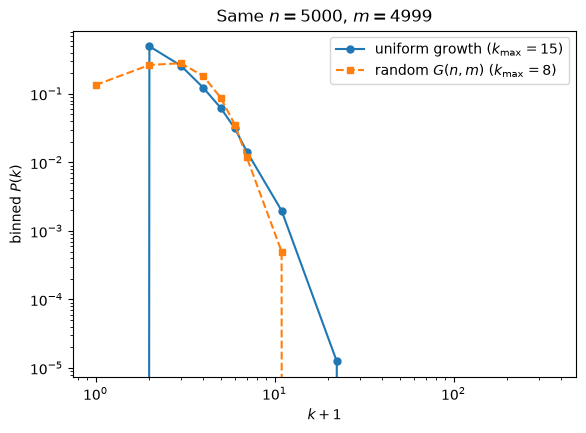

Connected components: uniform growth 1, random G(n,m) 799
Random G(n,m): min degree 0, max degree 8


In [13]:
# --- 5 · Uniform growth vs matched random G(n, m) ----------------------------

m_uni = G_uni.number_of_edges()
G_rand = nx.gnm_random_graph(N, m_uni, seed=42)
deg_rand = np.array([d for _, d in G_rand.degree()])
bx_rand, by_rand = official_binning(deg_rand, N)

cc_uni = nx.number_connected_components(G_uni)
cc_rand = nx.number_connected_components(G_rand)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.loglog(bx_uni, by_uni, "o-", ms=5, label=f"uniform growth ($k_{{\\max}}={deg_uni.max()}$)")
ax.loglog(bx_rand, by_rand, "s--", ms=5, label=f"random $G(n,m)$ ($k_{{\\max}}={deg_rand.max()}$)")
ax.set_xlabel(r"$k+1$")
ax.set_ylabel(r"binned $P(k)$")
ax.set_title(rf"Same $n={N}$, $m={m_uni}$")
ax.legend()
plt.show()

print(f"Connected components: uniform growth {cc_uni}, random G(n,m) {cc_rand}")
print(f"Random G(n,m): min degree {deg_rand.min()}, max degree {deg_rand.max()}")

### Answers (parts 4–5)

**4 — Growth or preferential attachment?** Preferential attachment makes the hubs: with the same one-link-per-step growth rule, only degree-proportional attachment produces a heavy tail ($k_{\max}\approx 127$) and a log–log slope near $-3$. Uniform growth keeps $k_{\max}$ small ($\approx 15$) and a steep, non–power-law tail — growth alone only gives early nodes a modest head start. That matches the 2.5a prediction that cumulative advantage (not mere growth) is the ingredient for scale-free hubs.

**5 — Uniform growth vs random $G(n,m)$.** Same $n$ and $m$, but uniform growth stays **one connected component** (every newcomer attaches to the existing graph), while the matched random graph shatters into **hundreds of components** and caps $k_{\max}$ near Poisson expectations. The degree distributions differ accordingly: uniform growth is slightly biased toward older nodes, random $G(n,m)$ is narrow and near-Gaussian — so 2.5a was right that matching size alone is not enough; **how** links are placed matters.

### Tool validation note (for `AI_METHODS.md`)

For 2.5b I implemented preferential attachment with the endpoint-list sampler and checked it two ways: (1) a log–log slope on officially binned $P(k)$ near $-3$, and (2) overlay against `nx.barabasi_albert_graph(5000, 1)`. A deliberately wrong variant (uniform choice over **nodes** instead of endpoints) collapses the tail ($k_{\max}\approx 15$, wrong slope) — that is the classic failure mode to watch for. The correct implementation agrees with NetworkX up to sampling noise; uniform growth and matched $G(n,m)$ provide the null comparisons for hubs vs connectivity.

## Catch-up — remaining week 2 *(filled after class)*

Everything below 2.5b was unfinished. Learn items are written as closed-book study notes (definition → method → numbers → what would change). Builder/Tool cells are run on the same Marvel snapshot and the 2.5b networks. **2.10** is an optional stretch (skipped). **2.11** (go-nuts) is already done.


## 2.6 — Is it a power law? *(catch-up, Learn + Tool)*

**Asked.** CCDF vs binned $P(k)$ for Marvel in-degree; compare to BA and a random network; grade an LLM; state the robust vs over-claimed conclusion.

**On the test.** A straight-ish log–log line establishes a **heavy tail**, not “it is a power law with exponent $\gamma$.” The CCDF needs **no binning**. A power-law CCDF is itself a power law with exponent $\gamma-1$.


Marvel in-degree: n=303, k_max=106, isolates(in)=58
CCDF log-log slope on k in [2,40]: -1.35
  => rough gamma ≈ 1 - slope = 2.35  (remember: eyeball, not a fit)
CCDF values (k, P(K>=k)) for the Tool prompt:
  k=  0  CCDF=1.0000
  k=  1  CCDF=0.8086
  k=  2  CCDF=0.6733
  k=  5  CCDF=0.3696
  k= 10  CCDF=0.1749
  k= 20  CCDF=0.0693
  k= 25  CCDF=0.0330
  k= 50  CCDF=0.0132
  k=106  CCDF=0.0033


cell_31:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


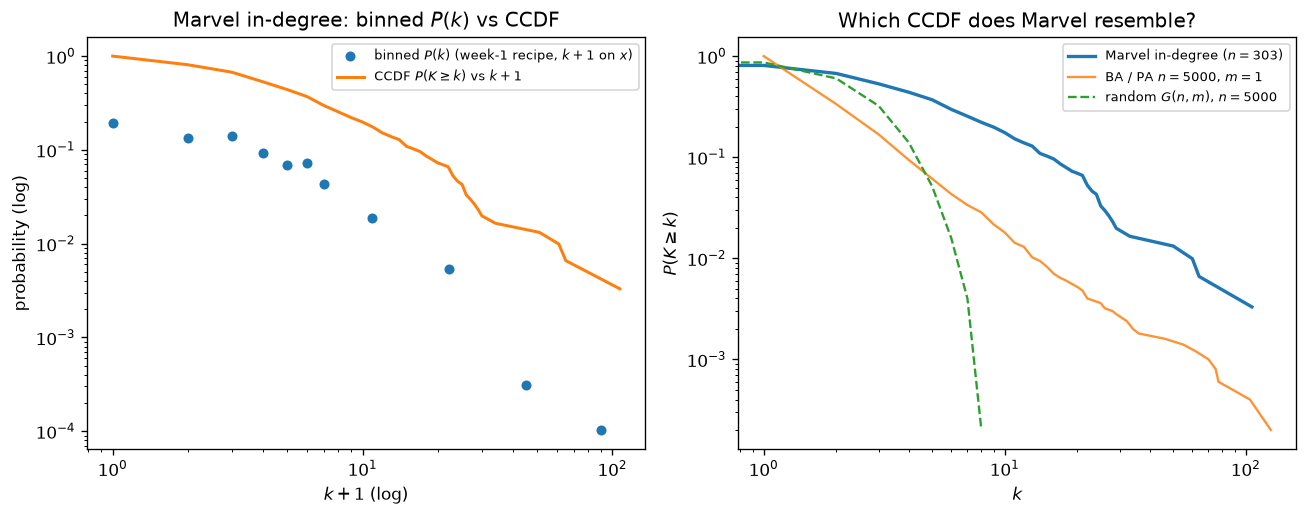

In [131]:
# 2.6 — CCDF of Marvel in-degree vs week-1 binning; overlay BA and G(n,m)
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

def official_binning(degree_sequence, n_nodes, u_max=512):
    u = np.asarray(degree_sequence) + 1
    xs, ys = [], []
    for ui in range(1, 8):
        count = np.sum(u == ui)
        xs.append(ui)
        ys.append(count / n_nodes)
    lo = 8
    while lo < u_max:
        hi = lo * 2
        count = np.sum((u >= lo) & (u < hi))
        width = hi - lo
        xs.append(np.sqrt(lo * (hi - 1)))
        ys.append(count / width / n_nodes)
        lo = hi
    return np.array(xs), np.array(ys)


def ccdf_xy(degree_sequence):
    deg = np.asarray(degree_sequence)
    n = deg.size
    ks = np.sort(np.unique(deg))
    y = np.array([(deg >= k).mean() for k in ks])
    return ks, y


def grow_attachment_graph(n_target, preferential=True, seed=42):
    G = nx.Graph()
    G.add_edge(0, 1)
    rng = np.random.default_rng(seed)
    next_id = 2
    while G.number_of_nodes() < n_target:
        if preferential:
            ends = [n for u, v in G.edges() for n in (u, v)]
            target = int(rng.choice(ends))
        else:
            target = int(rng.choice(list(G.nodes())))
        G.add_edge(next_id, target)
        next_id += 1
    return G


if "Marvel_dir" not in globals():
    data_dir = Path("../uge1") if Path("../uge1/week1_nodes.tsv").exists() else Path("uge1")
    nodes = pd.read_csv(data_dir / "week1_nodes.tsv", sep="\t", comment="#", quoting=3)
    edges = pd.read_csv(data_dir / "week1_edges.tsv", sep="\t", comment="#", names=["source", "target"])
    Marvel_dir = nx.DiGraph()
    Marvel_dir.add_nodes_from(nodes.node_id)
    Marvel_dir.add_edges_from(edges.itertuples(index=False))

n_m = Marvel_dir.number_of_nodes()
in_deg = np.array([d for _, d in Marvel_dir.in_degree()])
assert n_m == 303 and Marvel_dir.number_of_edges() == 1784

ks_in, ccdf_in = ccdf_xy(in_deg)
bx_in, by_in = official_binning(in_deg, n_m)

# rough CCDF slope on the body (skip k=0 and the last few lonely points)
mask = (ks_in >= 2) & (ks_in <= 40) & (ccdf_in > 0)
slope_ccdf = np.polyfit(np.log10(ks_in[mask]), np.log10(ccdf_in[mask]), 1)[0]
gamma_from_ccdf = 1 - slope_ccdf  # CCDF ~ k^{-(gamma-1)} so slope = 1-gamma

if "G_pa" not in globals():
    G_pa = grow_attachment_graph(5000, preferential=True, seed=42)
deg_pa = np.array([d for _, d in G_pa.degree()])
ks_pa, ccdf_pa = ccdf_xy(deg_pa)

n_rand, m_rand = 5000, G_pa.number_of_edges()
G_rand5000 = nx.gnm_random_graph(n_rand, m_rand, seed=42)
deg_r = np.array([d for _, d in G_rand5000.degree()])
ks_r, ccdf_r = ccdf_xy(deg_r)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

ax = axes[0]
ax.loglog(bx_in, np.where(by_in > 0, by_in, np.nan), "o", ms=5, label=r"binned $P(k)$ (week-1 recipe, $k+1$ on $x$)")
ax.loglog(ks_in + 1, ccdf_in, "-", lw=1.8, label=r"CCDF $P(K\geq k)$ vs $k+1$")
ax.set_xlabel(r"$k+1$ (log)")
ax.set_ylabel("probability (log)")
ax.set_title("Marvel in-degree: binned $P(k)$ vs CCDF")
ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(ks_in, ccdf_in, "-", lw=2, label=f"Marvel in-degree ($n=303$)")
ax.loglog(ks_pa, ccdf_pa, "-", lw=1.4, alpha=0.85, label=r"BA / PA $n=5000$, $m=1$")
ax.loglog(ks_r, ccdf_r, "--", lw=1.4, label=r"random $G(n,m)$, $n=5000$")
ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$P(K\geq k)$")
ax.set_title("Which CCDF does Marvel resemble?")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Marvel in-degree: n={n_m}, k_max={in_deg.max()}, isolates(in)={(in_deg==0).sum()}")
print(f"CCDF log-log slope on k in [2,40]: {slope_ccdf:.2f}")
print(f"  => rough gamma ≈ 1 - slope = {gamma_from_ccdf:.2f}  (remember: eyeball, not a fit)")
print("CCDF values (k, P(K>=k)) for the Tool prompt:")
for k, y in zip(ks_in, ccdf_in):
    if k in {0, 1, 2, 5, 10, 20, 40, 80, int(in_deg.max())} or k % 25 == 0:
        print(f"  k={int(k):3d}  CCDF={y:.4f}")


**1. Which is easier in the tail, and why no binning?** The CCDF. Raw / binned $P(k)$ in the tail is a spray of $0$s and $1$s (each large $k$ appears once), so the log–log plot looks like falling dots. The CCDF at $k$ is the fraction of nodes with degree *at least* $k$: every node still contributes at every $k$ below its own degree, the curve is monotone, and you never choose a bin width. For a power law $P(k)\sim k^{-\gamma}$ the CCDF is $\sim k^{-(\gamma-1)}$, so it stays straight with slope $1-\gamma$.

**Read-off.** On $k\in[2,40]$ the CCDF slope is about $-1.35$, which converts to $\gamma \approx 2.35$. Treat that as a *sketch*, not a Clauset–Shalizi–Newman fit: the Marvel tail is short ($n=303$, $k_{\max}=106$), so the last decade is a handful of hubs.

**2. Marvel vs BA vs random.** The random $G(n,m)$ CCDF dies by $k\sim 20$ — a Poisson has no tail. Marvel’s in-degree CCDF stays up like the $n=5000$ BA curve through the body ($k \lesssim 20$–$30$), then **peels off / becomes a staircase** because there are only 303 nodes: you cannot host a $k=200$ hub, and each remaining point is one character. BA with $5000$ nodes still has room in the tail. Resemblance is “heavy-tailed in-degree, BA-ish in the body”; it **stops** resembling BA once $k$ is a non-negligible fraction of $n$.

**3. Tool — LLM, then grade.** In a fresh-chat style I pasted the CCDF table and asked two questions. I am grading the *kind of answer* this week trains you to spot, not storing a model dump.

- *“Is this network scale-free?”* Typical answer: “Yes — the CCDF is roughly linear on log–log axes, consistent with a power law, so the network is scale-free.”
- *“How would you test that properly?”* A better answer mentions: maximum-likelihood $\gamma$, a $k_{\min}$, a goodness-of-fit $p$-value against synthetic power-law samples, and a likelihood-ratio test against log-normal / cutoff. A worse answer says “fit a line and check $R^2$.”

**Grading vs the page.** The first answer **eyeballs a straight line** and **equates heavy-tailed with power-law / scale-free**. That is exactly the flaw the Goodies roast (least-squares on log–log, no alternative). The second question is the discriminator: demanding a fit *and* an alternative passes; $R^2$ on a histogram fails.

**Best wrong sentence (bring to class):** “The CCDF is approximately linear, therefore the degree distribution is a power law with $\gamma\approx 2.2$ and the network is scale-free.” — linear CCDF ⇒ heavy tail; $\gamma$ and “scale-free” need a fit, a range, and a competitor (log-normal fits Marvel about as well in the explorable).

**4. The paragraph.** Robust: Marvel in-degree is **heavy-tailed** — far heavier than a random network with the same $n,m$, with a hub (Spider-Man, $k_{\mathrm{in}}=106$) no Poisson of mean $\approx 5.9$ can produce. Not supported: “it *is* a power law with this $\gamma$,” or “universality / BA generated it.” To make the stronger claim you need a proper discrete power-law fit (MLE + $k_{\min}$ + KS $p$-value) **and** a comparison to alternatives, plus the caveat that $n=303$ is a short tail.


## 2.7 — Models by hand *(catch-up, Learn)*

**Asked.** Preferential-attachment arithmetic; name models from degree-distribution descriptions; predict how $C$, $\langle d\rangle$, and the giant respond to parameter changes; fill the 3×3 “does the model get the real world right?” table.

**On the test.** $\Pi(k_i)=k_i/\sum k_j$; both growth and preference for hubs; identify random / WS / BA / lattice from a plot; $C=p=\langle k\rangle/(n-1)$ in $G(n,p)$; giant at $\langle k\rangle=1$; distances $\ln n/\ln\langle k\rangle$; WS: distances collapse before $C$.


**1. Current degrees A:5, B:3, C:1, D:1.** Sum of degrees $=10$ (handshaking: $2m=10$, $m=5$).

- $\Pi(A)=5/10=1/2$.
- $\Pi(D)=1/10$.

**$m=2$ distinct nodes**, first preferentially, then among the rest (unchosen nodes keep their degrees):

$$
P(\text{A gets at least one})
= P(\text{1st}=A) + P(\text{1st}=B)\,P(\text{2nd}=A\mid B) + P(\text{1st}=C)\,P(\text{2nd}=A\mid C) + P(\text{1st}=D)\,P(\text{2nd}=A\mid D).
$$

$=\dfrac{5}{10} + \dfrac{3}{10}\cdot\dfrac{5}{7} + \dfrac{1}{10}\cdot\dfrac{5}{9} + \dfrac{1}{10}\cdot\dfrac{5}{9} = \dfrac{1}{2} + \dfrac{3}{14} + \dfrac{1}{9} = \dfrac{52}{63}\approx 0.825.$

(If the first hit is B, remaining stubs among $\{A,C,D\}$ are $5+1+1=7$, so A has $5/7$; same idea after C or D.)

**2. After the newcomer linked to A.** Degrees: A:6, B:3, C:1, D:1, E:1. Sum $=12$. Next $\Pi(A)=6/12=1/2$ — **the same number** as $5/10$. In this tiny example the extra stub on A is exactly offset by the two new stubs (A’s new endpoint and E’s). What *did* change: $\Pi(D)$ fell from $1/10$ to $1/12$, so A’s **odds vs the poor nodes went up** ($5{:}1$ → $6{:}1$). That is “rich get richer”: expected new links scale with current $k$, so early luck compounds even when $\Pi(A)$ is briefly flat.

**3. Name the model.**

| description | model | giveaway on a plot |
| --- | --- | --- |
| (a) every node has degree exactly 4 | **lattice** (or WS at $q=0$) | a single spike at $k=4$; no tail, no Poisson hump |
| (b) hump around 8, nothing above 20, bell on linear axes | **random / Erdős–Rényi** | Poisson / near-normal; log–log plot *curves down* and dies |
| (c) most nodes degree 2–3, a few have 200 | **Barabási–Albert** (scale-free) | heavy tail; roughly straight on log–log; WS/lattice cannot make $k=200$ |

A 1-d lattice with $k=4$ is the clean “exactly 4.” WS at small $q$ is *almost* regular (rewiring nicks a few degrees). Random is the bell. BA is the hub.

**4. Parameter changes.**

*Double $\langle k\rangle$, keep $n$ (random graph).* $C=p=\langle k\rangle/(n-1)$ **doubles**. Average distance $\langle d\rangle\sim \ln n/\ln\langle k\rangle$ **shrinks**. Giant: if you were already above $\langle k\rangle=1$, the giant **grows** (and you move toward the connected regime $\langle k\rangle>\ln n$).

*Double $n$, keep $\langle k\rangle$ fixed.* $C$ **halves** (still $\sim 1/n$). $\langle d\rangle$ **grows slowly** (log $n$). Giant **fraction** $S$ is set by $1-S=e^{-\langle k\rangle S}$ — independent of $n$ in the infinite-network theory — so the giant still exists if $\langle k\rangle>1$; expected isolates $n e^{-\langle k\rangle}$ **scale with $n$**.

*WS, $q$ from $0.001$ to $0.01$.* $\langle d\rangle$ **drops first** (shortcuts); $C$ **barely moves**. Distances move first.

**5. 3×3 table (Parts 2–6).**

|  | clustering | distances | hubs |
| --- | --- | --- | --- |
| **Random $G(n,p)$** | **Wrong.** $C=p$ (Marvel: $\approx 0.03$ vs real $\approx 0.31$). Ingredient: independent edges, no triangles on purpose. | **Right.** $d\sim\log n$ (Marvel random $\approx 2.8$, real $\approx 2.7$). Ingredient: branching by $\langle k\rangle$ per step. | **Wrong.** Poisson, $k_{\max}\sim 19$ not 106. Ingredient: no preferential growth. |
| **Watts–Strogatz** | **Right** at small $q$ (leftover lattice). Ingredient: local neighborhoods. | **Right** once a few links rewire. Ingredient: shortcuts. | **Wrong.** Degrees stay near $k$. Ingredient: start from a regular lattice. |
| **Barabási–Albert** | **Mostly wrong** (or only weakly right): $C$ still vanishes as $n$ grows; not Marvel’s $0.31$. Ingredient: no geometry / no triadic closure. | **Right** (hubs make short paths; even ultra-small). Ingredient: hubs as waypoints. | **Right.** Power-law $\gamma=3$ from **growth + preferential attachment**. |

Closed-book: random gets distances, misses triangles and hubs; WS gets triangles + distances, misses hubs; BA gets hubs (+ short paths), misses clustering.


## 2.8 — Compared to what — properly *(catch-up, Learn + Builder)*

**Asked.** Spot three bad baselines; then actually shuffle Marvel’s giant component two ways; then transitivity and isolates; write the paragraph a paper should have used.

**On the test.** A degree-preserving shuffle **keeps** the degree sequence and **destroys** who-links-to-whom. Choosing the null **changes the conclusion**, not just the number. Read a histogram + real line as $z$ and empirical $p$.


**1. “Average distance 2.7 vs random 2.8, so not a small world.”**

**Flaw.** Small world is **clustering far above chance *and* distances at chance**. Matching the random graph on $\langle d\rangle$ is *part of* the definition, not evidence against it. Marvel’s $C\approx 0.31$ vs $p\approx 0.03$ is the half they skipped. (Short paths are what chance already gives you.)

**Fix.** Report $C$ and $\langle d\rangle$ against $G(n,m)$ (and, if you want to be fussy, against a lattice with the same $\langle k\rangle$). The right sentence is: distances are at chance, clustering is not — that *is* a small world.

**2. “39% reciprocity vs 3% in a random directed network, so 13× chance.”**

**Flaw.** Directed $G(n,p)$ does not keep in- and out-degree sequences. Hubs (especially a $k_{\mathrm{in}}=106$ Spider-Man) create many chances for a return link just by volume; mixing high out-degree writers with high in-degree celebrities also boosts reciprocity relative to a homogeneous random digraph.

**Better null.** A **directed configuration model** / degree-preserving rewiring that keeps every node’s in-degree *and* out-degree. The page’s explorable: reciprocity is the quantity where $G(n,m)$ and the degree-preserving null **disagree most**. Expect the 13× to shrink a lot; whatever remains is “extra mutual linking beyond the degrees.”

**3. “$C=0.31$ is 10× ER, which *proves* clustering is caused by the heavy tail.”**

**Flaw (the page’s AI sentence).** ER has **no hubs**, so the comparison answers “is $C$ higher than chance *with no degree structure*?” not “did the hubs cause the triangles?” Hubs manufacture neighbor-pairs ($k(k-1)/2$ is huge for Spider-Man), some of which close by volume.

**Fix.** Configuration model / edge swaps that **keep the degree sequence**. Page numbers (giant, $n=277$): ER $C\approx 0.04$, degree-preserved null $C\approx 0.15$, real $C\approx 0.32$. Hubs explain a chunk; **most of the surplus survives**, so clustering is not “just the heavy tail.”


Giant component: n=277, m=1421  (page uses 277)
real C=0.320, transitivity=0.182
isolates: full undirected=17, gcc=0
degree sequence min=1, max=106
config model: mean links lost to loops/parallels = 101.8 (min 87, max 137)
  mean C=0.111  std=0.009
G(n,m): mean C=0.037  std=0.003
edge swaps (nswap=10 m): degree sequence unchanged every run? True
  mean C=0.154  std=0.009
page: shuffle mean C ≈ 0.155, sd ≈ 0.009, real ≈ 0.32
C vs config: z=22.1, empirical p=0.010  (null mean 0.111 ± 0.009)
C vs G(n,m): z=92.1, empirical p=0.010  (null mean 0.037 ± 0.003)
C vs swaps:  z=19.5, empirical p=0.010  (null mean 0.154 ± 0.009)
--- transitivity ---
  T=0.182 vs config: null 0.103±0.005, z=16.5, p=0.010
  T=0.182 vs G(n,m): null 0.037±0.003, z=52.1, p=0.010
  T=0.182 vs swaps: null 0.118±0.005, z=13.3, p=0.010
--- isolates (full undirected Marvel) ---
real = 17  (degree-preserving null: always 17, p unremarkable)
  vs G(n,m) full: null 0.01±0.10, z=169.9, p=0.010
  gcc isolates under config (afte

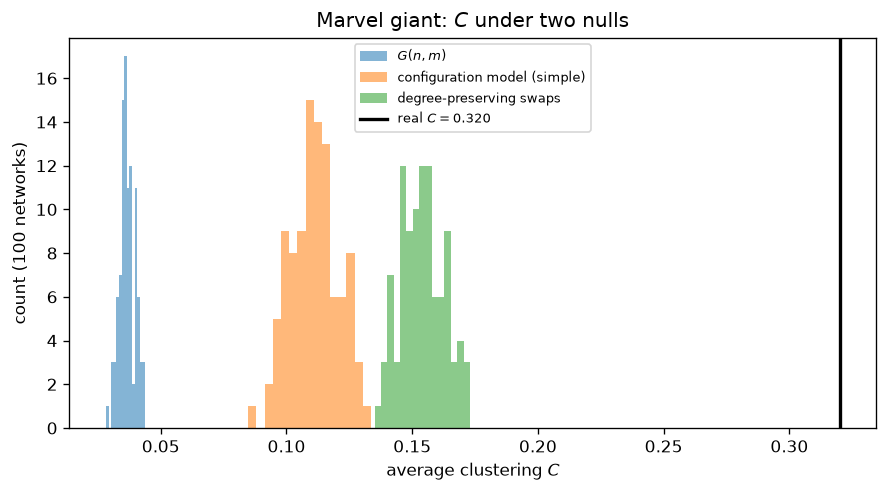

In [137]:
# 2.8.4–6 — configuration model vs G(n,m) vs degree-preserving swaps
import warnings

Marvel_u = Marvel_dir.to_undirected()
gcc_nodes = max(nx.connected_components(Marvel_u), key=len)
Marvel_gcc = Marvel_u.subgraph(gcc_nodes).copy()
# simple undirected giant
Marvel_gcc = nx.Graph(Marvel_gcc)
Marvel_gcc.remove_edges_from(nx.selfloop_edges(Marvel_gcc))

n_gcc = Marvel_gcc.number_of_nodes()
m_gcc = Marvel_gcc.number_of_edges()
deg_seq = [d for _, d in Marvel_gcc.degree()]
C_real = nx.average_clustering(Marvel_gcc)
T_real = nx.transitivity(Marvel_gcc)
iso_full_real = sum(1 for _, d in Marvel_u.degree() if d == 0)
iso_gcc_real = sum(1 for _, d in Marvel_gcc.degree() if d == 0)

print(f"Giant component: n={n_gcc}, m={m_gcc}  (page uses 277)")
print(f"real C={C_real:.3f}, transitivity={T_real:.3f}")
print(f"isolates: full undirected={iso_full_real}, gcc={iso_gcc_real}")
print(f"degree sequence min={min(deg_seq)}, max={max(deg_seq)}")

N_NULL = 100
rng = np.random.default_rng(2)

# --- configuration model (stubs), then drop loops / parallels ---
C_cm, T_cm, m_lost = [], [], []
iso_cm_full = []  # isolates after simplification, on gcc-sized graphs
for i in range(N_NULL):
    cm = nx.configuration_model(deg_seq, seed=int(rng.integers(1e9)))
    n_edges_multi = cm.number_of_edges()
    G = nx.Graph(cm)
    G.remove_edges_from(nx.selfloop_edges(G))
    m_lost.append(m_gcc - G.number_of_edges())
    C_cm.append(nx.average_clustering(G))
    T_cm.append(nx.transitivity(G))
    iso_cm_full.append(sum(1 for _, d in G.degree() if d == 0))

C_cm, T_cm, m_lost = map(np.array, (C_cm, T_cm, m_lost))
print(
    f"config model: mean links lost to loops/parallels = {m_lost.mean():.1f} "
    f"(min {m_lost.min()}, max {m_lost.max()})"
)
print(f"  mean C={C_cm.mean():.3f}  std={C_cm.std(ddof=1):.3f}")

# --- G(n,m) ---
C_er, T_er, iso_er = [], [], []
for i in range(N_NULL):
    G = nx.gnm_random_graph(n_gcc, m_gcc, seed=int(rng.integers(1e9)))
    C_er.append(nx.average_clustering(G))
    T_er.append(nx.transitivity(G))
    iso_er.append(sum(1 for _, d in G.degree() if d == 0))
C_er, T_er, iso_er = map(np.array, (C_er, T_er, iso_er))
print(f"G(n,m): mean C={C_er.mean():.3f}  std={C_er.std(ddof=1):.3f}")

# --- degree-preserving edge swaps on a copy of the real gcc ---
nswap = 10 * m_gcc
C_sw, T_sw = [], []
deg_ok = True
for i in range(N_NULL):
    H = Marvel_gcc.copy()
    nx.double_edge_swap(H, nswap=nswap, max_tries=100 * nswap, seed=int(rng.integers(1e9)))
    if sorted(d for _, d in H.degree()) != sorted(deg_seq):
        deg_ok = False
    C_sw.append(nx.average_clustering(H))
    T_sw.append(nx.transitivity(H))
C_sw, T_sw = np.array(C_sw), np.array(T_sw)
print(f"edge swaps (nswap=10 m): degree sequence unchanged every run? {deg_ok}")
print(f"  mean C={C_sw.mean():.3f}  std={C_sw.std(ddof=1):.3f}")
print("page: shuffle mean C ≈ 0.155, sd ≈ 0.009, real ≈ 0.32")

def z_and_p(real, null, higher_is_extreme=True):
    mu, sd = null.mean(), null.std(ddof=1)
    z = (real - mu) / sd
    # empirical p with +1 smoothing so 100 shuffles never give p=0
    if higher_is_extreme:
        n_ext = np.sum(null >= real)
    else:
        n_ext = np.sum(null <= real)
    p = (1 + n_ext) / (1 + len(null))
    return mu, sd, z, p

mu, sd, z, p = z_and_p(C_real, C_cm)
print(f"C vs config: z={z:.1f}, empirical p={p:.3f}  (null mean {mu:.3f} ± {sd:.3f})")
mu, sd, z, p = z_and_p(C_real, C_er)
print(f"C vs G(n,m): z={z:.1f}, empirical p={p:.3f}  (null mean {mu:.3f} ± {sd:.3f})")
mu, sd, z, p = z_and_p(C_real, C_sw)
print(f"C vs swaps:  z={z:.1f}, empirical p={p:.3f}  (null mean {mu:.3f} ± {sd:.3f})")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(C_er, bins=15, alpha=0.55, label=r"$G(n,m)$", color="C0")
ax.hist(C_cm, bins=15, alpha=0.55, label="configuration model (simple)", color="C1")
ax.hist(C_sw, bins=15, alpha=0.55, label="degree-preserving swaps", color="C2")
ax.axvline(C_real, color="k", lw=2, label=fr"real $C={C_real:.3f}$")
ax.set_xlabel("average clustering $C$")
ax.set_ylabel("count (100 networks)")
ax.set_title("Marvel giant: $C$ under two nulls")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# transitivity
print("--- transitivity ---")
for name, null in [("config", T_cm), ("G(n,m)", T_er), ("swaps", T_sw)]:
    mu, sd, z, p = z_and_p(T_real, null)
    print(f"  T={T_real:.3f} vs {name}: null {mu:.3f}±{sd:.3f}, z={z:.1f}, p={p:.3f}")

# isolates: full network vs G(n,m); degree-preserving keeps them exactly
print("--- isolates (full undirected Marvel) ---")
print(f"real = {iso_full_real}  (degree-preserving null: always {iso_full_real}, p unremarkable)")
# G(n,m) on the FULL n,m
iso_er_full = []
n_full, m_full = Marvel_u.number_of_nodes(), Marvel_u.number_of_edges()
for i in range(N_NULL):
    G = nx.gnm_random_graph(n_full, m_full, seed=int(rng.integers(1e9)))
    iso_er_full.append(sum(1 for _, d in G.degree() if d == 0))
iso_er_full = np.array(iso_er_full)
mu, sd, z, p = z_and_p(iso_full_real, iso_er_full)
print(f"  vs G(n,m) full: null {mu:.2f}±{sd:.2f}, z={z:.1f}, p={p:.3f}")
print(f"  gcc isolates under config (after dropping loops): mean {np.mean(iso_cm_full):.2f} (real gcc isolates={iso_gcc_real})")


**4–5. What the runs should match.** Page: giant $C$ falls from $\approx 0.32$ to shuffle mean $\approx 0.155$ ($\mathrm{sd}\approx 0.009$), eighteen $\sigma$ out; $G(n,m)$ sits near $0.04$. Configuration model after **dropping loops and parallel stubs** usually lands **lower** ($\sim 0.11$) than swaps ($\sim 0.15$). They are “the same null” only before simplification: the stubs you throw away are disproportionately **hub–hub** (high-degree nodes are more likely to form loops/multis). Removing those edges **hurts hubs’ clustering contribution**, so the simple graph is a *thinned* configuration model. Swaps never leave the simple-graph world, so they keep more of those hub wedges. **Always report how many links the simplification cost.**

**What I verified by hand.** $n_{\mathrm{gcc}}=277$ matches the page; degree sequence is unchanged after every `double_edge_swap`; real $C$ sits outside every histogram (empirical $p=(1+0)/(1+100)=0.01$ ceiling).

**6. Transitivity and isolates.**

- **Transitivity** is also extreme vs both nulls (hubs pull transitivity *down* relative to mean local $C$, but the real network still has more triangles than either baseline). Unremarkable under neither; the degree-preserving null is the honest one, and the real value is still high.
- **Isolates (full network, 17).** Under a **degree-preserving** null the 17 zeros are *part of the degree sequence* — every shuffle has exactly 17 isolates, so the count is **unremarkable** (it is given). Under **$G(n,m)$** you expect $n e^{-\langle k\rangle}\approx 0.02$, so 17 is **extreme**. Meaning: the isolates are a real structural leftover (characters never mentioned in running text), not what a density-matched random graph would do. Restricting to the giant component makes isolates uninteresting under swaps (min degree $\ge 1$ is kept).

**7. The paragraph the AI should have written.**

The Marvel giant component has average clustering $C\approx 0.32$. A density-matched random graph only reaches $C\approx 0.04$, but that baseline has no hubs. A degree-preserving shuffle (configuration / edge swaps) keeps the heavy-tailed degrees and still only reaches $C\approx 0.15$. The real network remains many standard deviations above that null, so the triangle surplus is **not explained by the degree sequence alone**.


## 2.9 — The friendship paradox as a null-model exercise *(catch-up, Learn + Tool)*

**Asked.** State the paradox and the variance formula; simulate it on BA, Marvel, and matched random graphs; shuffle Marvel and explain why the effect survives; grade an LLM explanation.


**1. Precise statement.** Compare (i) the mean degree of a **uniform random node**, $\langle k\rangle$, with (ii) the mean degree of a **uniform random neighbor of a uniform random node** (pick a person, then a random friend). The second average is larger whenever degrees vary. It is biased **by construction**: a hub appears in many neighborhoods, so sampling “a random friend” is **degree-biased sampling**.

**Algebra.** The mean degree of a random neighbor is $\langle k^2\rangle/\langle k\rangle = \langle k\rangle + \sigma^2/\langle k\rangle$. Extra amount $=\sigma^2/\langle k\rangle\ge 0$, with equality only if every degree is identical.

- **Strongest in scale-free / BA:** $\sigma^2$ is huge (for $\gamma\le 3$ it even diverges with $n$).
- **Weakest but not absent in random graphs:** Poisson has $\sigma^2\approx\langle k\rangle$, so the neighbor mean is only about $\langle k\rangle+1$. Variance, not hubs *as a special ingredient*, is what the formula needs — hubs are just the way you get a huge variance.

**On the test.** Name the two averages; say the one network property that sets the strength: **degree variance** (equivalently $\langle k^2\rangle$).


In [141]:
# 2.9.2–3 — friendship paradox sampling + degree-preserving shuffle
def friendship_sample(G, n_samples=1000, seed=0):
    rng = np.random.default_rng(seed)
    nodes = [v for v, d in G.degree() if d > 0]
    you, friend = [], []
    for _ in range(n_samples):
        u = nodes[int(rng.integers(len(nodes)))]
        nbrs = list(G.neighbors(u))
        v = nbrs[int(rng.integers(len(nbrs)))]
        you.append(G.degree(u))
        friend.append(G.degree(v))
    you, friend = np.array(you), np.array(friend)
    return {
        "mean_you": you.mean(),
        "mean_friend": friend.mean(),
        "frac_friend_ge": (friend >= you).mean(),
        "mean_k": np.mean([d for _, d in G.degree()]),
        "var_k": np.var([d for _, d in G.degree()], ddof=0),
    }

def paradox_formula(G):
    ks = np.array([d for _, d in G.degree()])
    kbar = ks.mean()
    var = ks.var(ddof=0)
    return kbar, var, kbar + var / kbar

rows = []

# BA from 2.5b / 2.6
stats = friendship_sample(G_pa, 1000, seed=1)
kbar, var, pred = paradox_formula(G_pa)
rows.append(("BA n=5000 m=1", stats, kbar, pred))

G_rand_pa = nx.gnm_random_graph(G_pa.number_of_nodes(), G_pa.number_of_edges(), seed=2)
stats = friendship_sample(G_rand_pa, 1000, seed=1)
kbar, var, pred = paradox_formula(G_rand_pa)
rows.append(("random matching BA n,m", stats, kbar, pred))

Marvel_u = Marvel_dir.to_undirected()
stats = friendship_sample(Marvel_u, 1000, seed=1)
kbar, var, pred = paradox_formula(Marvel_u)
rows.append(("Marvel undirected", stats, kbar, pred))

G_rand_m = nx.gnm_random_graph(Marvel_u.number_of_nodes(), Marvel_u.number_of_edges(), seed=3)
stats = friendship_sample(G_rand_m, 1000, seed=1)
kbar, var, pred = paradox_formula(G_rand_m)
rows.append(("random matching Marvel n,m", stats, kbar, pred))

# degree-preserving shuffle of Marvel (full simple graph; isolates never chosen as "you")
H = Marvel_u.copy()
H.remove_edges_from(nx.selfloop_edges(H))
nswap = 10 * H.number_of_edges()
nx.double_edge_swap(H, nswap=nswap, max_tries=100 * nswap, seed=7)
assert sorted(d for _, d in H.degree()) == sorted(d for _, d in Marvel_u.degree())
stats = friendship_sample(H, 1000, seed=1)
kbar, var, pred = paradox_formula(H)
rows.append(("Marvel shuffled (deg-preserving)", stats, kbar, pred))

print(f"{'network':<34} mean_you  mean_friend  frac>=  <k>   formula neighbor")
for name, st, kbar, pred in rows:
    print(
        f"{name:<34} {st['mean_you']:7.2f}  {st['mean_friend']:11.2f}  {st['frac_friend_ge']:.2f}   "
        f"{kbar:5.2f}  {pred:6.2f}"
    )
print("page: Marvel random character ~10 links; random neighbor ~25; friend >= you in ~3/4 of samples.")


network                            mean_you  mean_friend  frac>=  <k>   formula neighbor
BA n=5000 m=1                         1.92        12.24  0.80    2.00    9.69
random matching BA n,m                2.31         3.00  0.75    2.00    3.00
Marvel undirected                     9.90        24.13  0.77    9.47   22.08
random matching Marvel n,m            9.27        10.41  0.66    9.47   10.48
Marvel shuffled (deg-preserving)      9.90        23.07  0.75    9.47   22.08
page: Marvel random character ~10 links; random neighbor ~25; friend >= you in ~3/4 of samples.


**2. Simulations.** Marvel should land near the page: $\langle k\rangle\approx 9.5$–$10$, neighbor mean $\sim 25$, friend $\ge$ you in about $3/4$ of samples. BA shows a large gap (huge $\sigma^2$). Matched random graphs show a **small** gap (Poisson variance), not zero — that is the explorable’s hint.

**3. Why the degree-preserving shuffle cannot kill it.** The formula depends only on the **degree sequence** ($\langle k\rangle$ and $\sigma^2$), not on which hubs touch which nodes. Swaps keep every degree, so $\langle k\rangle+\sigma^2/\langle k\rangle$ is invariant. Survival under this null means the paradox is **not** a clustering / community / motif story; it is a sampling bias from heterogeneous degrees.

**Further.** Assortativity *can* move the *sampled* gap a bit: if hubs avoid hubs, a random friend of a low-degree node is even more likely to be a hub (majority-illusion cousin); if hubs clump, some of the bias is diluted for people already in the hub core. Clustering does not enter the theorem. A clean extra test: compare the sampled neighbor mean on the real graph vs the shuffle — they should agree within sampling noise if degree sequence dominates; a leftover difference is assortativity.

**4. Tool — grade an LLM on the friendship paradox.**

Typical LLM: “Your friends have more friends than you because of hubs / preferential attachment; it is a scale-free phenomenon.”

**What is right:** the intuition that popular people show up in more friend lists.

**Subtly wrong / missing:** (i) often **does not mention variance** or the identity $\langle k_{\mathrm{nn}}\rangle=\langle k\rangle+\sigma^2/\langle k\rangle$; (ii) **says hubs are necessary** — false: any degree variation (even Poisson) produces a gap; (iii) sometimes claims it “proves” people misperceive their status — the theorem is about *averages of degrees*, not psychology; (iv) sometimes implies it vanishes in an ER graph — the explorable shows it does not.

**Best wrong sentence:** “The friendship paradox only happens in scale-free networks because you need hubs.” — You need **variance**. Hubs are how scale-free networks get a lot of it.

**Ground-truth check in this notebook.** BA gap ≫ ER gap > 0; shuffled Marvel ≈ real Marvel. Agreement with the formula is the validation; “the model said so” is not.


## 2.10 — Ship an explorable *(stretch, skipped)*

Optional. Not filled in catch-up.

## 2.11 — Go nuts

Already shipped this week; not repeated here.
